In [1]:
import importlib
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc)

In [2]:
import set_paths
import src.utils as utils
import src.models_tools as mt

In [3]:
data = pd.read_csv(r'..\data\clean.csv')
features = data.iloc[:, 1:]
target = data.iloc[:, 0]
n_splits = 5
seed = 1105
fold_maker = StratifiedKFold(n_splits= n_splits, shuffle= True, random_state= seed)
metrics = [accuracy_score, recall_score, precision_score, f1_score]

In [4]:
def fold_eval_metrics(y_test: np.array, y_pred: np.array, y_proba: np.array,
                      metrics_dict: dict[list], 
                      roc_dict: dict[list],
                      prc_dict: dict[list], 
                      metrics:list = metrics):

    for i, metric_name in enumerate(metrics_dict.keys()):
        metric_value = metrics[i](y_test, y_pred)
        metrics_dict[metric_name].append(metric_value)
    #Calculamos las curvas ROC y PRC:
        #ROC
    roc = roc_curve(y_test, y_proba)
    for i, key in enumerate(roc_dict.keys()):
        roc_dict[key].append(roc[i])

        #PRC
    prc = precision_recall_curve(y_test, y_proba)
    for i, key in enumerate(prc_dict.keys()):
        prc_dict[key].append(prc[i])

## Como se estableció en el notebook anterior, las clases están muy desbalanceadas. Se probará un modelo sin resamplear los datos como BaseLine, de arquitectura SVM, con pesos de clase inversamente proporcionales a sus frecuencias

# SVM

In [5]:
bl_svc_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_svc_roc = copy.deepcopy(utils.roc_eval)
bl_svc_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]
    #Definimos los objetos que escalan:
    scaler = MinMaxScaler()
    #Reescalamos:
    x_trn_scld = scaler.fit_transform(x_trn)
    x_test_scld = scaler.transform(x_test)
    #Definimos el modelo (svc):
    svc = SVC(kernel = "rbf", gamma = "scale" , random_state= seed, probability= True, class_weight= "balanced")
    #Entrenamos el modelo:
    svc.fit(x_trn_scld, y_trn)
    #Usamos el modelo para predecir:
    y_pred = svc.predict(x_test_scld)
    y_proba = svc.predict_proba(x_test_scld)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_svc_metrics_eval,
                      roc_dict= bl_svc_roc,
                      prc_dict = bl_svc_prc)

In [6]:
bl_svc_metric_mean = mt.metrics_stats(bl_svc_metrics_eval)
print("Métricas promedio para el SVM base:")
bl_svc_metric_mean.head()

Métricas promedio para el SVM base:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.8547,0.0100
1,recall,0.8091,0.0698
2,precision,0.1584,0.0160
3,f1,0.2648,0.0255


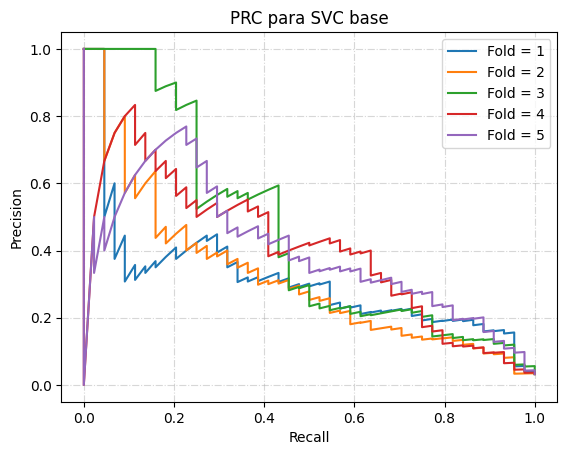

In [7]:
recall, precision = bl_svc_prc["recall"], bl_svc_prc["precision"]
plt.title("PRC para SVC base")
for i in range(n_splits):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

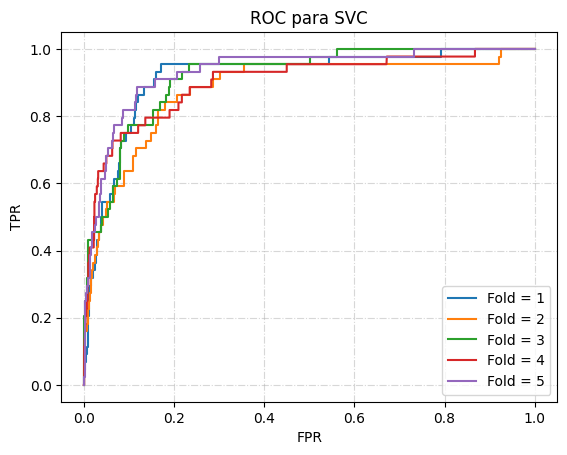

In [30]:
fpr, tpr = bl_svc_roc["fpr"], bl_svc_roc["tpr"]
plt.title("ROC para SVC")
for i in range(n_splits):
    plt.plot(fpr[i], tpr[i], label = f"Fold = {i+1}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

# Regresión Logística

In [8]:
bl_lr_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_lr_roc = copy.deepcopy(utils.roc_eval)
bl_lr_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]
    #Definimos los objetos que escalan:
    scaler = MinMaxScaler()
    #Reescalamos:
    x_trn_scld = scaler.fit_transform(x_trn)
    x_test_scld = scaler.transform(x_test)
    #Definimos el modelo (lr):
    lr = LogisticRegression(random_state=seed,
                            fit_intercept= True, 
                            solver = "newton-cholesky",
                            tol=1e-6, 
                            warm_start= False,
                            class_weight="balanced", max_iter=1000)

    lr.fit(x_trn_scld, y_trn)
    #Usamos el modelo para predecir:
    y_pred = lr.predict(x_test_scld)
    y_proba = lr.predict_proba(x_test_scld)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_lr_metrics_eval,
                      roc_dict= bl_lr_roc,
                      prc_dict = bl_lr_prc)

In [9]:
bl_lr_metric_mean = mt.metrics_stats(bl_lr_metrics_eval)
print("Métricas promedio para el modelo de regresión logística:")
bl_lr_metric_mean.head()

Métricas promedio para el modelo de regresión logística:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.8594,0.0027
1,recall,0.8182,0.0557
2,precision,0.1636,0.0071
3,f1,0.2727,0.0128


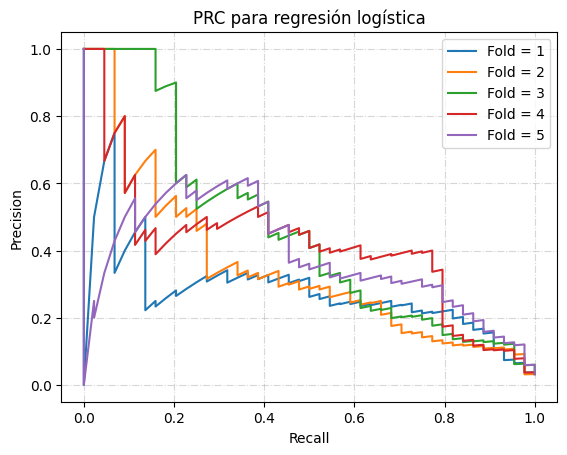

In [10]:
recall, precision = bl_lr_prc["recall"], bl_lr_prc["precision"]
plt.title("PRC para regresión logística")
for i in range(n_splits):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

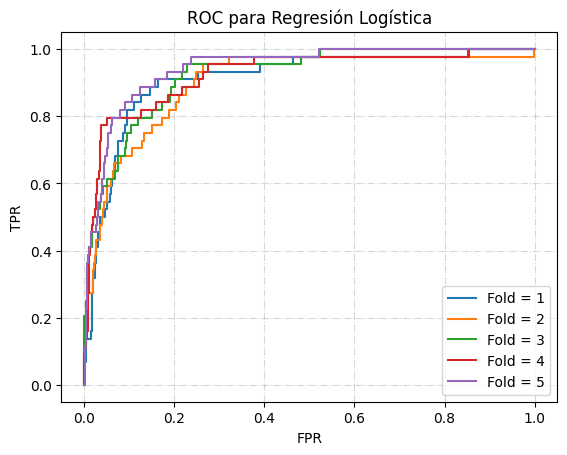

In [29]:
fpr, tpr = bl_lr_roc["fpr"], bl_lr_roc["tpr"]
plt.title("ROC para Regresión Logística")
for i in range(n_splits):
    plt.plot(fpr[i], tpr[i], label = f"Fold = {i+1}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

# RANDOM FOREST

In [11]:
bl_rf_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_rf_roc = copy.deepcopy(utils.roc_eval)
bl_rf_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]

    rf = RandomForestClassifier(random_state=seed, 
                                min_samples_split=10, n_estimators=500, n_jobs=-1, class_weight="balanced")
    #Entrenamos el modelo:
    rf.fit(x_trn, y_trn)
    #Usamos el modelo para predecir:
    y_pred = rf.predict(x_test)
    y_proba = rf.predict_proba(x_test)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_rf_metrics_eval,
                      roc_dict= bl_rf_roc,
                      prc_dict = bl_rf_prc)

In [12]:
bl_rf_metric_mean = mt.metrics_stats(bl_rf_metrics_eval)
print("Métricas promedio para el Random Forest:")
bl_rf_metric_mean.head()

Métricas promedio para el Random Forest:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.9698,0.0021
1,recall,0.2045,0.0380
2,precision,0.6012,0.0877
3,f1,0.3031,0.0485


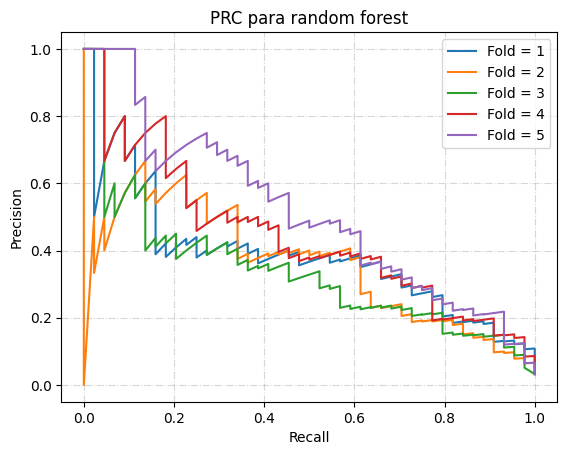

In [21]:
recall, precision = bl_rf_prc["recall"], bl_rf_prc["precision"]
plt.title("PRC para random forest")
for i in range(n_splits):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

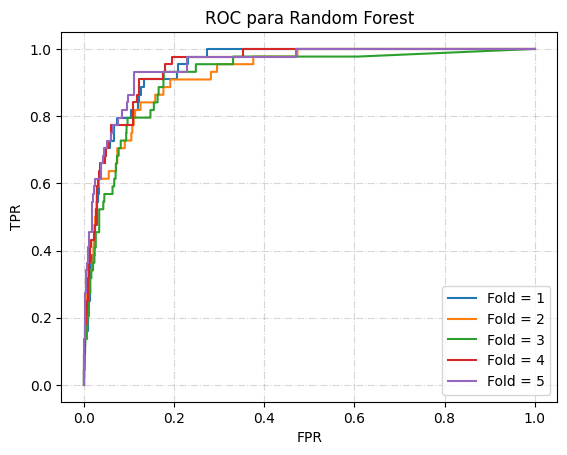

In [28]:
fpr, tpr = bl_rf_roc["fpr"], bl_rf_roc["tpr"]
plt.title("ROC para Random Forest")
for i in range(n_splits):
    plt.plot(fpr[i], tpr[i], label = f"Fold = {i+1}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

# XGBOOST

In [14]:
from xgboost import XGBClassifier

In [15]:
bl_xgb_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_xgb_roc = copy.deepcopy(utils.roc_eval)
bl_xgb_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]

    n_pos = (y_trn == 1).sum()
    n_neg = (y_trn == 0).sum()

    xgb = XGBClassifier(random_state=seed, 
                         n_estimators=500, n_jobs=-1, scale_pos_weight= n_neg/n_pos)
    #Entrenamos el modelo:
    xgb.fit(x_trn, y_trn)
    #Usamos el modelo para predecir:
    y_pred = xgb.predict(x_test)
    y_proba = xgb.predict_proba(x_test)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_xgb_metrics_eval,
                      roc_dict= bl_xgb_roc,
                      prc_dict = bl_xgb_prc)

In [16]:
bl_xgb_metric_mean = mt.metrics_stats(bl_xgb_metrics_eval)
print("Métricas promedio para el XGBoost:")
bl_xgb_metric_mean.head()

Métricas promedio para el XGBoost:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.9701,0.0029
1,recall,0.3727,0.0422
2,precision,0.5694,0.0686
3,f1,0.4452,0.0216


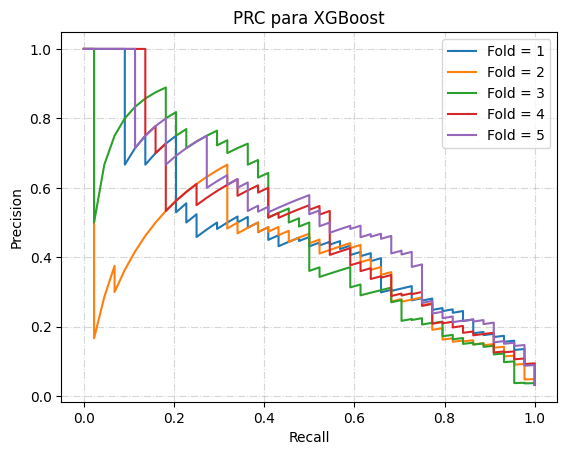

In [17]:
recall, precision = bl_xgb_prc["recall"], bl_xgb_prc["precision"]
plt.title("PRC para XGBoost")
for i in range(n_splits):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

## La regresión logística tiene el mayor recall en promedio, pero el xgboost tiene las mejores curvas PR, lo cual indica que, ajustando el treshold, se puede mejorar mucho el recall sin comprometer demasiado la precisión

In [18]:
bl_xgb_metrics_eval = copy.deepcopy(utils.metrics_eval)
bl_xgb_roc = copy.deepcopy(utils.roc_eval)
bl_xgb_prc = copy.deepcopy(utils.prc_eval)

for train_index, test_index in fold_maker.split(features, target):
    #train-test split:
    x_trn, y_trn = features.iloc[train_index], target.iloc[train_index]
    x_test, y_test = features.iloc[test_index], target.iloc[test_index]

    smote = BorderlineSMOTE(sampling_strategy= "minority", random_state = seed, k_neighbors= 2, m_neighbors= 5)
    #enn = EditedNearestNeighbours(kind_sel= "all", n_neighbors= 5, sampling_strategy= "all")
    #smoteenn = SMOTEENN(smote = smote, enn = enn)
    x_trn_res, y_trn_res = smote.fit_resample(x_trn, y_trn)


    n_pos = (y_trn == 1).sum()
    n_neg = (y_trn == 0).sum()

    xgb = XGBClassifier(random_state=seed, 
                         n_estimators=500, n_jobs=-1, scale_pos_weight= n_neg/n_pos)
    #Entrenamos el modelo:
    xgb.fit(x_trn_res, y_trn_res)
    #Usamos el modelo para predecir:
    y_pred = xgb.predict(x_test)
    y_proba = xgb.predict_proba(x_test)[:, 1]
    #Calculamos las métricas:
    fold_eval_metrics(y_test = y_test, y_pred = y_pred, y_proba = y_proba, 
                      metrics_dict= bl_xgb_metrics_eval,
                      roc_dict= bl_xgb_roc,
                      prc_dict = bl_xgb_prc)

In [19]:
bl_xgb_metric_mean = mt.metrics_stats(bl_xgb_metrics_eval)
print("Métricas promedio para el XGBoost:")
bl_xgb_metric_mean.head()

Métricas promedio para el XGBoost:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.9633,0.0032
1,recall,0.4682,0.0232
2,precision,0.4408,0.0411
3,f1,0.4525,0.0211


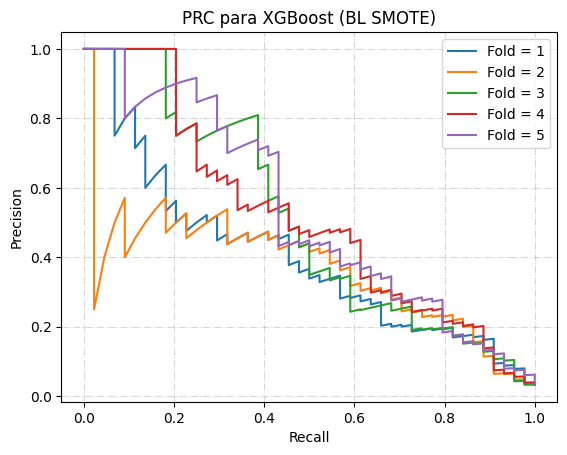

In [35]:
recall, precision = bl_xgb_prc["recall"], bl_xgb_prc["precision"]
plt.title("PRC para XGBoost (BL SMOTE)")
for i in range(n_splits):
    plt.plot(recall[i], precision[i], label = f"Fold = {i+1}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

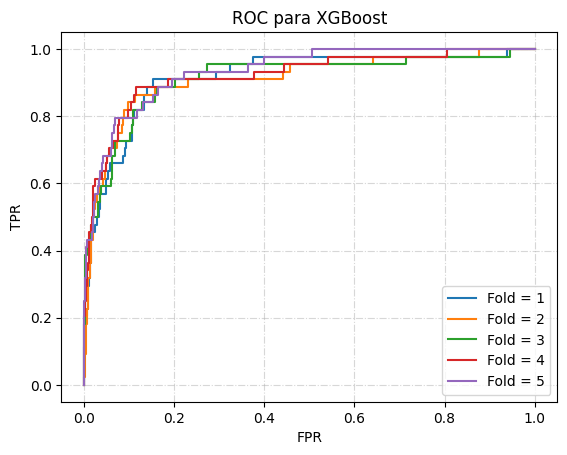

In [27]:
fpr, tpr = bl_xgb_roc["fpr"], bl_xgb_roc["tpr"]
plt.title("ROC para XGBoost")
for i in range(n_splits):
    plt.plot(fpr[i], tpr[i], label = f"Fold = {i+1}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(linestyle = "dashdot", alpha = 0.5)
plt.legend()

In [34]:
auc(bl_xgb_prc["recall"][3], bl_xgb_prc["precision"][3])

0.5125406071108508